In [1]:
import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.6.0+cu126
torchvision: 0.21.0+cu126
CUDA: True
GPU: NVIDIA A100-SXM4-80GB


In [2]:
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset

from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    T5ForConditionalGeneration,
    T5TokenizerFast,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

PROJECT_ROOT= Path('.').resolve()
PROCESSED_DIR= PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR= PROJECT_ROOT / 'checkpoints' / 'run4' 
HP_DIR= PROJECT_ROOT / 'checkpoints' / 'hp_search'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HP_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE= PROCESSED_DIR / 'wikisql_t5_train.pt'
VAL_FILE= PROCESSED_DIR / 'wikisql_t5_val.pt'

MODEL_NAME= 't5-base'

#hyperparams (updated from run2)
LR= 3e-4    
BATCH_SIZE= 32
EPOCHS= 20      #was 10
WARMUP_STEPS= 1000    #was 500
MAX_GEN_LEN= 128
LORA_R= 32      
LORA_ALPHA= 64      
LORA_MODULES= ['q', 'k', 'v', 'o', 'wi', 'wo'] 

# Set True for SQL-label retrain — HP search already done in run3
SKIP_HP_SEARCH = True

print('Project root:',PROJECT_ROOT)
print('Train file:', TRAIN_FILE)
print('Val file:',VAL_FILE)
print('Output dir:',OUTPUT_DIR)

/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /projects/e32706/sct1077
Train file: /projects/e32706/sct1077/data/processed/wikisql_t5_train.pt
Val file: /projects/e32706/sct1077/data/processed/wikisql_t5_val.pt
Output dir: /projects/e32706/sct1077/checkpoints/run4


In [3]:
class TensorDictDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
        self.length = encodings['input_ids'].size(0)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        return {
            'input_ids':self.encodings['input_ids'][idx],
            'attention_mask':self.encodings['attention_mask'][idx],
            'labels':self.encodings['labels'][idx],
        }


def load_tensor_dict(path: Path):
    if not path.exists():
        raise FileNotFoundError(f'Missing preprocessed file: {path}')
    data = torch.load(path, weights_only=False)
    required = {'input_ids', 'attention_mask', 'labels'}
    if not required.issubset(set(data.keys())):
        raise ValueError(f'{path} missing keys. Expected: {required}')
    return data


train_enc=load_tensor_dict(TRAIN_FILE)
val_enc=load_tensor_dict(VAL_FILE)

train_dataset=TensorDictDataset(train_enc)
val_dataset=TensorDictDataset(val_enc)

print('train examples:',len(train_dataset))
print('validation examples:', len(val_dataset))

train examples: 56355
validation examples: 8421


In [5]:
# Pre-flight: labels must be SQL strings, not WikiSQL JSON structs
from pathlib import Path
import torch
from transformers import T5TokenizerFast

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SAMPLE_SIZE = 200

def _resolve_tokenizer():
    for path in (
        PROJECT_ROOT / "checkpoints" / "run3",
        PROJECT_ROOT / "checkpoints" / "best_lora",
        PROJECT_ROOT / "checkpoints" / "run4",
    ):
        if path.is_dir() and (path / "tokenizer.json").exists():
            print(f"Using local tokenizer: {path}")
            return T5TokenizerFast.from_pretrained(str(path))
    print("Using Hugging Face tokenizer: t5-base")
    return T5TokenizerFast.from_pretrained("t5-base")

def _verify_labels(path: Path, tokenizer, sample_size: int = 200) -> bool:
    if not path.exists():
        print(f"MISSING: {path}")
        return False

    data = torch.load(path, map_location="cpu", weights_only=False)
    n = min(sample_size, data["labels"].size(0))
    sql_n = struct_n = other_n = 0
    examples = {"sql": [], "struct": [], "other": []}

    for i in range(n):
        ids = [x for x in data["labels"][i].tolist() if x != -100]
        label = tokenizer.decode(ids, skip_special_tokens=True).strip()
        if label.upper().startswith("SELECT"):
            sql_n += 1
            if len(examples["sql"]) < 2:
                examples["sql"].append(label)
        elif label.startswith("{") or '"sel"' in label:
            struct_n += 1
            if len(examples["struct"]) < 2:
                examples["struct"].append(label)
        else:
            other_n += 1
            if len(examples["other"]) < 2:
                examples["other"].append(label)

    print(f"\n{path.name}: {data['labels'].size(0)} examples")
    print(f"  checked first {n}: {sql_n} SQL, {struct_n} struct, {other_n} other")
    if examples["sql"]:
        print(f"  SQL sample: {examples['sql'][0]}")
    if examples["struct"]:
        print(f"  STRUCT sample: {examples['struct'][0]}")

    ok = struct_n == 0 and sql_n == n
    print("  PASS" if ok else "  FAIL — regenerate with NL2SQL_preprocessing.ipynb")
    return ok

tok = _resolve_tokenizer()
ok = True
for name in ("wikisql_t5_train.pt", "wikisql_t5_val.pt"):
    ok &= _verify_labels(PROCESSED_DIR / name, tok, SAMPLE_SIZE)

if not ok:
    raise RuntimeError("Label verification failed. Regenerate data/processed/*.pt before training.")
print("\nLabel verification passed.")

Using Hugging Face tokenizer: t5-base

wikisql_t5_train.pt: 56355 examples
  checked first 200: 200 SQL, 0 struct, 0 other
  SQL sample: SELECT Notes WHERE Current slogan = 'SOUTH AUSTRALIA'
  PASS

wikisql_t5_val.pt: 8421 examples
  checked first 200: 200 SQL, 0 struct, 0 other
  SQL sample: SELECT Position WHERE School/Club Team = 'Butler CC (KS)'
  PASS

Label verification passed.


In [6]:
tokenizer = T5TokenizerFast.from_pretrained(MODEL_NAME)
def build_model(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.1, target_modules=LORA_MODULES):
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=r,
        lora_alpha=lora_alpha,
        target_modules=target_modules,
        lora_dropout=lora_dropout,
    )
    base  = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
    model = get_peft_model(base, lora_config)
    return model

build_model().print_trainable_parameters()

Loading weights: 100%|██████████| 257/257 [00:00<00:00, 8212.97it/s]


trainable params: 12,976,128 || all params: 235,879,680 || trainable%: 5.5012


In [7]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions= predictions[0]

    if predictions.ndim == 3:
        predictions = np.argmax(predictions, axis=-1)

    pad_id= tokenizer.pad_token_id
    vocab_size= tokenizer.vocab_size

    predictions= np.asarray(predictions, dtype=np.int64)
    labels= np.asarray(labels,dtype=np.int64)

    predictions= np.where(predictions== -100, pad_id, predictions)
    labels= np.where(labels== -100, pad_id, labels)

    predictions= np.clip(predictions, 0, vocab_size - 1)
    labels= np.clip(labels, 0, vocab_size - 1)

    decoded_preds= tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels= tokenizer.batch_decode(labels,skip_special_tokens=True)

    exact_match = sum(
        pred.strip() == label.strip()
        for pred, label in zip(decoded_preds, decoded_labels)
    ) / max(1, len(decoded_preds))

    return {'exact_match': exact_match}

In [8]:
if not SKIP_HP_SEARCH:
    get_ipython().system('pip install optuna')
else:
    print('SKIP_HP_SEARCH=True — skip optuna install')

SKIP_HP_SEARCH=True — skip optuna install


In [9]:
if SKIP_HP_SEARCH:
    print('SKIP_HP_SEARCH=True — run the next cell for best hyperparams from run3')
else:
    import optuna

    _current_r = {'value': LORA_R}

    def model_init_hp():
        return build_model(
            r= _current_r['value'],
            lora_alpha = _current_r['value'] * 2,
        )

    def optuna_hp_space(trial):
        r = trial.suggest_categorical('lora_r', [16, 32, 64])
        _current_r['value'] = r
        return {
            'learning_rate':trial.suggest_float('learning_rate', 1e-4, 5e-4, log=True),
            'per_device_train_batch_size': trial.suggest_categorical('per_device_train_batch_size', [16, 32]),
            'weight_decay':trial.suggest_float('weight_decay', 0.0, 0.1),
            'warmup_steps':trial.suggest_int('warmup_steps', 200, 1000, step=200),
        }

    hp_args = Seq2SeqTrainingArguments(
        output_dir= str(HP_DIR),
        num_train_epochs= 6,#max per trial; Hyperband prunes most at epoch 2
        per_device_train_batch_size = 32,
        per_device_eval_batch_size  = 64,
        bf16= torch.cuda.is_available(),
        fp16= False,
        eval_strategy= 'epoch',
        save_strategy= 'no',
        predict_with_generate= False,    
        logging_steps= 200,
        report_to= 'none',
    )

    hp_trainer = Seq2SeqTrainer(
        model_init= model_init_hp,
        args= hp_args,
        train_dataset= train_dataset,
        eval_dataset= val_dataset,
        processing_class = tokenizer,
        compute_metrics= None,               
    )

    best_run = hp_trainer.hyperparameter_search(
        direction= 'minimize',#minimise val loss
        backend= 'optuna',
        hp_space= optuna_hp_space,
        n_trials= 12,#reduced from 20
        pruner= optuna.pruners.HyperbandPruner(
            min_resource= 1,#prune after just 1 epoch if bad
            max_resource= 6,
            reduction_factor= 3,
        ),
    )

    print('\nBest trial hyperparams:', best_run.hyperparameters)

    LR= best_run.hyperparameters.get('learning_rate',LR)
    BATCH_SIZE= best_run.hyperparameters.get('per_device_train_batch_size',BATCH_SIZE)
    WARMUP_STEPS = best_run.hyperparameters.get('warmup_steps',WARMUP_STEPS)
    LORA_R= best_run.hyperparameters.get('lora_r',LORA_R)
    LORA_ALPHA= LORA_R * 2
    print(f'Using: LR={LR}, BATCH={BATCH_SIZE}, WARMUP={WARMUP_STEPS}, r={LORA_R}, alpha={LORA_ALPHA}')

SKIP_HP_SEARCH=True — run the next cell for best hyperparams from run3


In [2]:
#best trial hyperparams from hp search
LR = 0.0004331450653013155
BATCH_SIZE = 16
WARMUP_STEPS = 200
WEIGHT_DECAY = 0.057593095881329284   
LORA_R = 32
LORA_ALPHA = 64    
LORA_MODULES = ['q', 'k', 'v', 'o', 'wi', 'wo']
EPOCHS = 20        
MAX_GEN_LEN = 128


In [3]:
from transformers import DataCollatorForSeq2Seq
from transformers import TrainerCallback

model = build_model(r=LORA_R, lora_alpha=LORA_ALPHA)
model.print_trainable_parameters()
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=False)
training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR),
    #save by steps to have more granular control
    save_strategy='epoch',
    eval_strategy='epoch',
    #keeping more checkpoints so rotation doesn't delete the best
    save_total_limit=2,         
    #explicitly save the best model to a separate directory
    load_best_model_at_end=True,
    metric_for_best_model='exact_match',
    greater_is_better=True,
    predict_with_generate= True, 
    generation_max_length= MAX_GEN_LEN,
    logging_steps= 100,
    report_to= 'none',
    weight_decay=WEIGHT_DECAY, 
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    warmup_steps=WARMUP_STEPS,
    bf16=torch.cuda.is_available(),
)
    

class SaveBestLoraCallback(TrainerCallback):
    def __init__(self, save_path):
        self.best_metric = 0.0
        self.save_path   = Path(save_path)

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        score = metrics.get('eval_exact_match', 0.0)
        if score > self.best_metric:
            self.best_metric = score
            model.save_pretrained(self.save_path)
            print(f'New best exact_match={score:.4f} → saved to {self.save_path}')

best_lora_dir = PROJECT_ROOT / 'checkpoints' / 'best_lora'
best_lora_dir.mkdir(parents=True, exist_ok=True)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[SaveBestLoraCallback(best_lora_dir)],  
)

print('Trainer initialised. Ready to train.')

NameError: name 'build_model' is not defined

In [ ]:
train_result = trainer.train()

print('\nTraining complete.')
print('Train metrics:', train_result.metrics)

eval_metrics = trainer.evaluate(max_length=MAX_GEN_LEN)
print('Validation metrics:', eval_metrics)

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)
print('Saved model artifacts to', OUTPUT_DIR)

Epoch,Training Loss,Validation Loss,Exact Match
1,0.118902,0.085075,0.659185
2,0.098017,0.075514,0.681748
3,0.087625,0.070148,0.702411
4,0.081661,0.066369,0.712386
5,0.068719,0.068282,0.713454
6,0.064556,0.066607,0.718917
7,0.059881,0.065913,0.719748
8,0.052947,0.063768,0.727586
9,0.048165,0.064205,0.738036
10,0.049525,0.064074,0.730198


New best exact_match=0.6592 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.6817 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7024 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7124 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7135 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7189 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7197 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7276 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7380 → saved to /projects/e32706/sct1077/checkpoints/best_lora
New best exact_match=0.7421 → saved to /projects/e32706/sct1077/checkpoints/best_lora


Loading training history from /Users/srijareddy/Documents/GitHub/NL2SQL/checkpoints/run4/checkpoint-56368/trainer_state.json


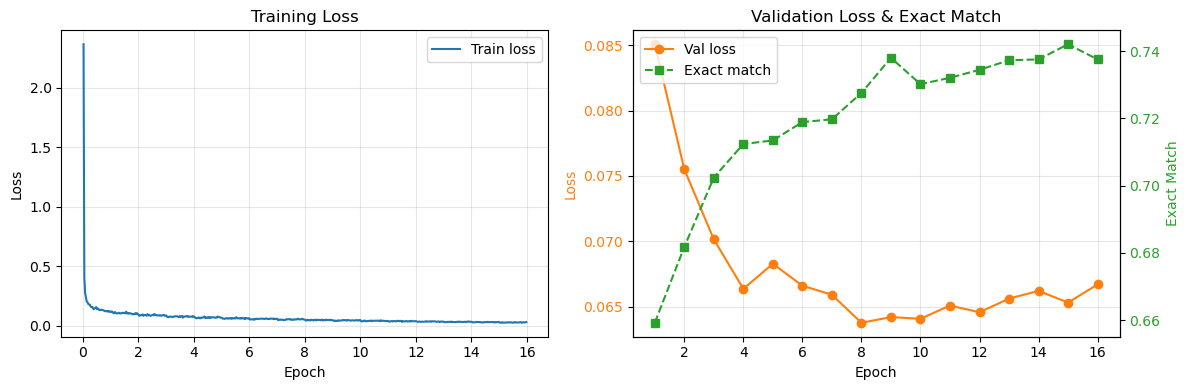

Final train loss: 0.0312
Final val loss: 0.0667
Final val exact match: 0.7376


In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve()
RUN_DIR = PROJECT_ROOT / 'checkpoints' / 'run4'


def load_training_history():
    if 'trainer' in globals():
        return trainer.state.log_history

    state_files = sorted(
        RUN_DIR.glob('checkpoint-*/trainer_state.json'),
        key=lambda p: int(p.parent.name.split('-')[1]),
    )
    if not state_files:
        raise FileNotFoundError(
            f'No trainer_state.json found under {RUN_DIR}. '
            'Copy checkpoints from the cluster or rerun training.'
        )
    latest = state_files[-1]
    print(f'Loading training history from {latest}')
    return json.loads(latest.read_text())['log_history']


history = load_training_history()

train_epochs      = [entry['epoch'] for entry in history if 'loss' in entry and 'eval_loss' not in entry]
train_losses      = [entry['loss']  for entry in history if 'loss' in entry and 'eval_loss' not in entry]

eval_epochs       = [entry['epoch']for entry in history if 'eval_loss' in entry]
eval_losses       = [entry['eval_loss']for entry in history if 'eval_loss' in entry]
eval_exact_match  = [entry.get('eval_exact_match') for entry in history if 'eval_loss' in entry]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_epochs, train_losses, color='tab:blue', label='Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

if eval_epochs:
    axes[1].plot(eval_epochs, eval_losses, 'o-', color='tab:orange', label='Val loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss', color='tab:orange')
    axes[1].tick_params(axis='y', labelcolor='tab:orange')
    axes[1].grid(True, alpha=0.3)

    lines, labels = axes[1].get_legend_handles_labels()

    if any(m is not None for m in eval_exact_match):
        ax2 = axes[1].twinx()
        ax2.plot(eval_epochs, eval_exact_match, 's--', color='tab:green', label='Exact match')
        ax2.set_ylabel('Exact Match', color='tab:green')
        ax2.tick_params(axis='y', labelcolor='tab:green')
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines  += lines2
        labels += labels2

    axes[1].legend(lines, labels, loc='upper left')
    axes[1].set_title('Validation Loss & Exact Match')
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Final train loss: {train_losses[-1]:.4f}')
if eval_losses:
    print(f'Final val loss: {eval_losses[-1]:.4f}')
if eval_exact_match and eval_exact_match[-1] is not None:
    print(f'Final val exact match: {eval_exact_match[-1]:.4f}')